In [1]:
# Imports
import torch
import timm
import torch.nn as nn
import numpy as np
import pandas as pd
import torchvision.transforms as T
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, resnet50
from torchmetrics.classification import (
    MultilabelAveragePrecision,
    MultilabelF1Score,
    MultilabelAccuracy,
    MultilabelRecall,
    MultilabelPrecision
)
from pathlib import Path
from PIL import Image
from typing import Literal
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor

/home/mahrad/miniconda3/envs/arcis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Confings
DATA_DIR = Path("artifacts/data/FloodNet-Supervised_v1.0")
MODEL_DIR = Path("artifacts/models")
EXPERIMENT_DIR = Path("Results/DeiT-Tiny")
MODEL_NAME = "DeiT-T"
MULTILABEL_NAMES = [
    "buildingAny",
    "buildingFlooded",
    "roadAny",
    "roadFlooded",
    "water",
    "tree",
    "vehicle",
    "pool",
    "grass"
]
NUM_LABELS = len(MULTILABEL_NAMES)
NUM_WORKERS = 32
PREFETCH_FACTOR = 1

LR = 1e-4
WEIGHT_DECAY = 1e-4
FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0
THRESHOLD = 0.5

EPOCHS = 100
PATIENCE = 10
BATCH_SIZE = 32

SEED = 888
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Num Labels: {NUM_LABELS}")

Device: cuda
Num Labels: 9


In [3]:
# Let's load the data locally and turn it into a Multi-Label classification dataset.
# If a pixel in an image has the value c, then label c is present.
class FloodNetMultiLabelDataset(Dataset):
    def __init__(
            self,
            root,
            split,
            imageSize
    ):
        self.root = Path(root)
        self.split = split
        self.imageDir = self.root / split / f"{split}-org-img"
        self.maskDir = self.root / split / f"{split}-label-img"
        self.images = sorted(self.imageDir.glob("*.jpg"))
        self.imageTF = T.Compose(
            [
                T.Resize((imageSize, imageSize)),
                T.ToTensor(),
                T.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]
                )
            ]
        )
        self.labels = self.precomputeLabels()

    def __len__(self):
        return len(self.images)
    
    def maskToMultiLabel(self, mask):
        present = np.bincount(mask.reshape(-1), minlength=10) > 0

        return torch.tensor(
            [
                present[1] or present[2],  # buildingAny
                present[1],                # buildingFlooded
                present[3] or present[4],  # roadAny
                present[3],                # roadFlooded
                present[5],                # water
                present[6],                # tree
                present[7],                # vehicle
                present[8],                # pool
                present[9],                # grass
            ],
            dtype=torch.float32,
        )

    def loadLabel(self, imagePath):
        maskPath = self.maskDir / f"{imagePath.stem}_lab.png"
        with Image.open(maskPath) as maskImage:
            mask = np.array(maskImage.convert("L"))
        return self.maskToMultiLabel(mask)

    def __getitem__(self, idx):
        imagePath = self.images[idx]
        image = Image.open(imagePath).convert("RGB")
        image = self.imageTF(image)
        labels = self.labels[idx]
        return image, labels
    
    def precomputeLabels(self):
        with ThreadPoolExecutor(max_workers=32) as executor:
            labels = list(
                tqdm(
                    executor.map(self.loadLabel, self.images),
                    total=len(self.images),
                    desc=f"Precomputing {self.split} labels"
                )
            )
        return torch.stack(labels)
    
trainDS = FloodNetMultiLabelDataset(DATA_DIR, split="train", imageSize=224)
valDS = FloodNetMultiLabelDataset(DATA_DIR, split="val", imageSize=224)
testDS = FloodNetMultiLabelDataset(DATA_DIR, split="test", imageSize=224)

trainLoader = DataLoader(trainDS, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, prefetch_factor=PREFETCH_FACTOR)
valLoader = DataLoader(valDS, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, prefetch_factor=PREFETCH_FACTOR)
testLoader = DataLoader(testDS, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, prefetch_factor=PREFETCH_FACTOR)

# Smoke test
images, labels = next(iter(trainLoader))
print(f"Image tensor shape: {images.shape}")
print(f"Label tensor shape: {labels.shape}")
print(MULTILABEL_NAMES)
print(labels[0])

Precomputing test labels: 100%|██████████| 448/448 [00:06<00:00, 72.41it/s] 


Image tensor shape: torch.Size([32, 3, 224, 224])
Label tensor shape: torch.Size([32, 9])
['buildingAny', 'buildingFlooded', 'roadAny', 'roadFlooded', 'water', 'tree', 'vehicle', 'pool', 'grass']
tensor([0., 0., 1., 0., 0., 1., 1., 0., 1.])


In [ ]:
# Let's analyze our label distribution
def countLabels(dataset, split):
    counts = torch.zeros(NUM_LABELS, dtype=torch.long)
    for _, labels in tqdm(dataset, desc=f"Counting {split} labels"):
        counts += labels.long()
    total = len(dataset)
    return pd.DataFrame(
        {
            "split": split,
            "label": MULTILABEL_NAMES,
            "count": counts.numpy(),
            "ratio": (counts.float() / total).numpy(),
            "percent": (counts.float() / total * 100).numpy()
        }
    )

labelStats = pd.concat(
    [
        countLabels(trainDS, "train"),
        countLabels(valDS, "val"),
        countLabels(testDS, "test")
    ],
    ignore_index=True
)
labelStatsPivot = labelStats.pivot(
    index="label",
    columns="split",
    values=["count", "percent"]
)
print(labelStatsPivot)

Counting test labels: 100%|██████████| 448/448 [00:35<00:00, 12.47it/s]

                 count                   percent                      
split             test   train    val       test      train        val
label                                                                 
buildingAny      199.0   633.0  197.0  44.419643  43.806229  43.777779
buildingFlooded   47.0   149.0   49.0  10.491072  10.311419  10.888888
grass            414.0  1331.0  416.0  92.410713  92.110733  92.444443
pool              96.0   331.0  104.0  21.428572  22.906574  23.111111
roadAny          277.0   865.0  276.0  61.830360  59.861595  61.333336
roadFlooded       49.0   162.0   53.0  10.937500  11.211073  11.777778
tree             364.0  1156.0  362.0  81.250000  80.000000  80.444443
vehicle          166.0   496.0  151.0  37.053570  34.325260  33.555557
water            183.0   668.0  208.0  40.848213  46.228374  46.222221


In [4]:
# Let's write a func that loads a model from local, given its name
def loadModel(
  modelName: Literal["ResNet-18", "ResNet-50", "DeiT-T", "DeiT-S"],
  numLabels      
):
    if modelName == "ResNet-18":
        model = resnet18(weights=None)
        checkpointPath = MODEL_DIR / "resnet18.pth"
        stateDict = torch.load(checkpointPath, map_location=DEVICE)
        model.load_state_dict(stateDict)
        inFeatures = model.fc.in_features
        model.fc = nn.Linear(inFeatures, numLabels)
    elif modelName == "ResNet-50":
        model = resnet50(weights=None)
        checkpointPath = MODEL_DIR / "resnet50.pth"
        stateDict = torch.load(checkpointPath, map_location=DEVICE)
        model.load_state_dict(stateDict)
        inFeatures = model.fc.in_features
        model.fc = nn.Linear(inFeatures, numLabels)
    elif modelName == "DeiT-T":
        model = timm.create_model(
            "deit_tiny_patch16_224",
            pretrained=False,
            num_classes=1000
        )
        checkpointPath = MODEL_DIR / "deitTiny.pth"
        checkpoint = torch.load(checkpointPath, map_location=DEVICE)
        model.load_state_dict(checkpoint["model"], strict=True)
        model.reset_classifier(numLabels)
    elif modelName == "DeiT-S":
        model = timm.create_model(
            "deit_small_patch16_224",
            pretrained=False,
            num_classes=1000
        )
        checkpointPath = MODEL_DIR / "deitSmall.pth"
        checkpoint = torch.load(checkpointPath, map_location=DEVICE)
        model.load_state_dict(checkpoint["model"], strict=True)
        model.reset_classifier(numLabels)

    return model

In [5]:
# Let's define our Focal Loss, evaluation, and train functions
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction: Literal["mean", "sum"] = "mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none"
        )
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        focalWeight = (1 - pt).pow(self.gamma)
        alphaT = torch.where(
            targets == 1,
            torch.full_like(targets, self.alpha),
            torch.full_like(targets, 1 - self.alpha)
        )
        focalWeight = alphaT * focalWeight
        loss = focalWeight * bce

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        
        return loss

def evaluate(model, dataLoader, threshold=0.5, method: Literal["micro", "macro"] | None = "macro"):
    model.eval()

    metrics = {
        "AP": MultilabelAveragePrecision(
            num_labels=NUM_LABELS,
            average=method
        ).to(DEVICE),
        "F1": MultilabelF1Score(
            num_labels=NUM_LABELS,
            threshold=threshold,
            average=method
        ).to(DEVICE),
        "Accuracy": MultilabelAccuracy(
            num_labels=NUM_LABELS,
            threshold=threshold,
            average=method
        ).to(DEVICE),
        "Recall": MultilabelRecall(
            num_labels=NUM_LABELS,
            threshold=threshold,
            average=method
        ).to(DEVICE),
        "Precision": MultilabelPrecision(
            num_labels=NUM_LABELS,
            threshold=threshold,
            average=method
        ).to(DEVICE)
    }

    perLabelMode = method is None
    if perLabelMode:
        totalNLL = torch.zeros(NUM_LABELS, device=DEVICE)
    else:
        totalNLL = 0.0
    
    totalSamples = 0

    valBar = tqdm(
    dataLoader,
    desc=f"Validating",
    leave=False
    )
    with torch.no_grad():
        for images, labels in valBar:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE).float()
            logits = model(images)

            perElementNLL = nn.functional.binary_cross_entropy_with_logits(
                logits,
                labels,
                reduction="none"
            )
            batchSize = images.size(0)
            if perLabelMode:
                totalNLL += perElementNLL.sum(dim=0)
            else:
                totalNLL += perElementNLL.mean().item() * batchSize
            totalSamples += batchSize
            probs = torch.sigmoid(logits)
            intLabels = labels.int()
            for metric in metrics.values():
                metric.update(probs, intLabels)
    
    if perLabelMode:
        results = {
            "label": MULTILABEL_NAMES,
            "nll": (totalNLL / totalSamples).detach().cpu().numpy()
        }
        for name, metric in metrics.items():
            results[name] = metric.compute().detach().cpu().numpy()
        return pd.DataFrame(results)
    else:
        results = {
            "nll": totalNLL / totalSamples
        }
        for name, metric in metrics.items():
            results[name] = metric.compute().item()
        return results

def train(
        model,
        trainLoader,
        valLoader,
        testLoader,
        numEpochs
):
    model = model.to(DEVICE)
    trainCriterion = FocalLoss(
        alpha=FOCAL_ALPHA,
        gamma=FOCAL_GAMMA
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )
    history = []
    bestScore = float("-inf")
    epochsWithoutImprovement = 0
    for epoch in range(1, numEpochs + 1):
        model.train()
        totalTrainLoss = 0.0
        totalSamples = 0

        trainBar = tqdm(
            trainLoader,
            desc=f"Training Epoch {epoch:03d}/{EPOCHS}",
            leave=False
        )
        for images, labels in trainBar:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE).float()
            optimizer.zero_grad()
            logits = model(images)
            loss = trainCriterion(logits, labels)
            loss.backward()
            optimizer.step()
            batchSize = images.size(0)
            totalTrainLoss += loss.item() * batchSize
            totalSamples += batchSize
        
        trainFocalLoss = totalTrainLoss / totalSamples
        valMetrics = evaluate(model, valLoader, threshold=THRESHOLD)
        row = {
            "epoch": epoch,
            "trainFocalLoss": trainFocalLoss,
            **{f"val_{k}": v for k, v in valMetrics.items()}
        }
        history.append(row)
        
        msg = (
            f"Epoch {epoch:03d}/{numEpochs} | "
            f"Train Loss: {trainFocalLoss:.4f} ||| "
            f"NLL: {valMetrics['nll']:.4f} | "
            f"AP: {valMetrics['AP']:.4f} | "
            f"F1: {valMetrics['F1']:.4f} | "
            f"Acc: {valMetrics['Accuracy']:.4f} | "
            f"Recall: {valMetrics['Recall']:.4f} | "
            f"Precision: {valMetrics['Precision']:.4f}"
        )
        if valMetrics["AP"] > bestScore:
            bestScore = valMetrics["AP"]
            epochsWithoutImprovement = 0
            torch.save(
                {
                    "epoch": epoch,
                    "stateDict": model.state_dict(),
                    "trainLoss": trainFocalLoss,
                    "valMetrics": valMetrics
                },
                EXPERIMENT_DIR / "best_checkpoint.pt"
            )
            msg += " [BEST]"
        else:
            epochsWithoutImprovement += 1

        if epochsWithoutImprovement >= PATIENCE:
            msg += " [EARLY STOPPED]"
            print(msg)
            break

        print(msg)
    return model, pd.DataFrame(history)


In [6]:
model = loadModel(MODEL_NAME, numLabels=NUM_LABELS)
model, history = train(
    model=model,
    trainLoader=trainLoader,
    valLoader=valLoader,
    testLoader=testLoader,
    numEpochs=EPOCHS
)

Epoch 001/100 | Train Loss: 0.0372 ||| NLL: 0.3414 | AP: 0.9525 | F1: 0.7837 | Acc: 0.8590 | Recall: 0.6799 | Precision: 0.9583 [BEST]


Epoch 002/100 | Train Loss: 0.0188 ||| NLL: 0.2686 | AP: 0.9703 | F1: 0.8757 | Acc: 0.9062 | Recall: 0.8138 | Precision: 0.9603 [BEST]


Epoch 003/100 | Train Loss: 0.0106 ||| NLL: 0.2289 | AP: 0.9696 | F1: 0.8881 | Acc: 0.9227 | Recall: 0.8413 | Precision: 0.9560


Epoch 004/100 | Train Loss: 0.0069 ||| NLL: 0.2051 | AP: 0.9749 | F1: 0.9053 | Acc: 0.9267 | Recall: 0.8594 | Precision: 0.9645 [BEST]


Epoch 005/100 | Train Loss: 0.0036 ||| NLL: 0.1723 | AP: 0.9778 | F1: 0.9332 | Acc: 0.9412 | Recall: 0.9334 | Precision: 0.9335 [BEST]


...

Epoch 043/100 | Train Loss: 0.0000 ||| NLL: 0.1362 | AP: 0.9821 | F1: 0.9392 | Acc: 0.9509 | Recall: 0.9278 | Precision: 0.9518


Epoch 044/100 | Train Loss: 0.0000 ||| NLL: 0.1362 | AP: 0.9821 | F1: 0.9389 | Acc: 0.9506 | Recall: 0.9272 | Precision: 0.9517


Epoch 045/100 | Train Loss: 0.0000 ||| NLL: 0.1361 | AP: 0.9821 | F1: 0.9390 | Acc: 0.9509 | Recall: 0.9279 | Precision: 0.9515


Epoch 046/100 | Train Loss: 0.0000 ||| NLL: 0.1360 | AP: 0.9821 | F1: 0.9389 | Acc: 0.9509 | Recall: 0.9277 | Precision: 0.9516


Epoch 047/100 | Train Loss: 0.0000 ||| NLL: 0.1360 | AP: 0.9820 | F1: 0.9386 | Acc: 0.9506 | Recall: 0.9268 | Precision: 0.9518 [EARLY STOPPED]


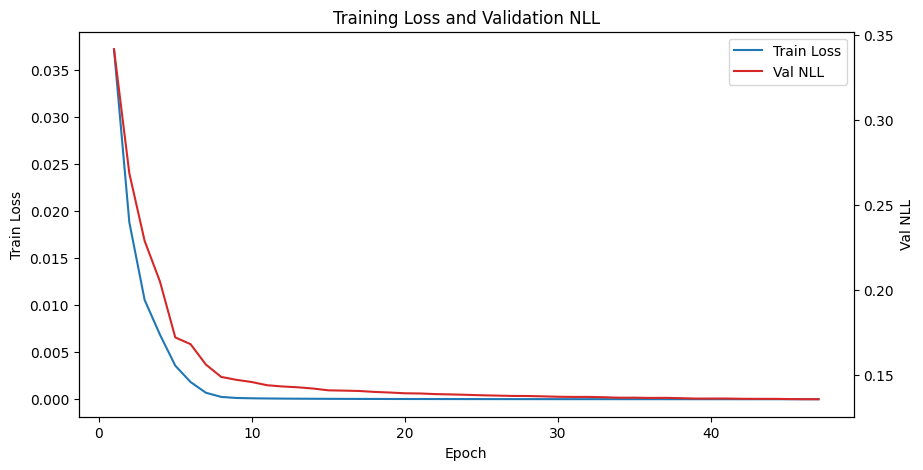

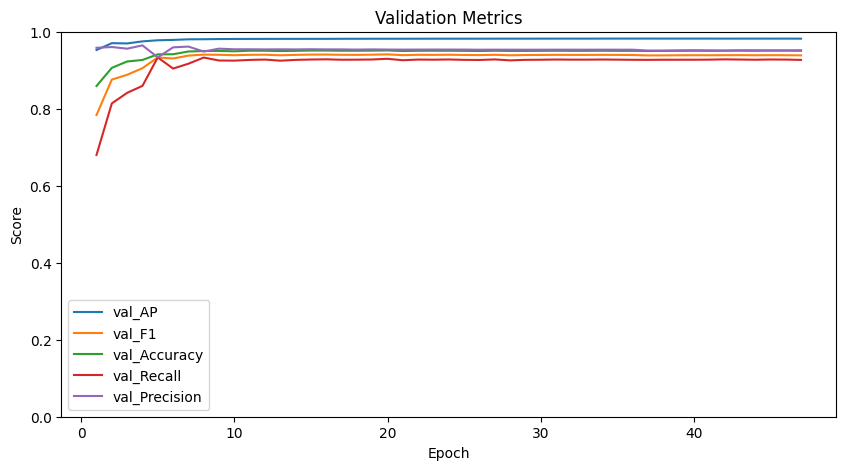

In [7]:
# Plot the history
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(history["epoch"], history["trainFocalLoss"], label="Train Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss")
ax1.tick_params(axis="y")

ax2 = ax1.twinx()
ax2.plot(history["epoch"], history["val_nll"], label="Val NLL", color="tab:red")
ax2.set_ylabel("Val NLL")
ax2.tick_params(axis="y")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Training Loss and Validation NLL")
plt.savefig(EXPERIMENT_DIR / "lossAndNLL.png")
plt.show()

valMetricsCols = [
    "val_AP",
    "val_F1",
    "val_Accuracy",
    "val_Recall",
    "val_Precision"
]
plt.figure(figsize=(10, 5))
for col in valMetricsCols:
    plt.plot(history["epoch"], history[col], label=col)
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.ylim(0, 1)
plt.legend()
plt.savefig(EXPERIMENT_DIR / "validationMetrics.png")
plt.show()

In [6]:
# Let's load the best checkpoint and calculate the per label metrics
def loadBestCheckpoint(
        modelName,
        checkpointPath="best_checkpoint.pt"
):
    model = loadModel(modelName, NUM_LABELS).to(DEVICE)
    checkpoint = torch.load(checkpointPath, map_location=DEVICE)
    model.load_state_dict(checkpoint["stateDict"])
    return model

model = loadBestCheckpoint("ResNet-18", "Results/ResNet-18/best_checkpoint.pt")
perLabelMetrics = evaluate(model, testLoader, threshold=0.5, method=None)
perLabelMetrics

,label,nll,AP,F1,Accuracy,Recall,Precision
0,buildingAny,0.134554,0.992940,0.956298,0.962054,0.934673,0.978947
1,buildingFlooded,0.077991,0.978058,0.957447,0.991071,0.957447,0.957447
2,roadAny,0.152960,0.992352,0.950459,0.939732,0.935018,0.966418
3,roadFlooded,0.055931,0.992086,0.960000,0.991071,0.979592,0.941176
4,water,0.241222,0.954556,0.874652,0.899554,0.857924,0.892045
5,tree,0.211730,0.996351,0.957386,0.933036,0.925824,0.991176
6,vehicle,0.242124,0.910186,0.875776,0.910714,0.849398,0.903846
7,pool,0.143588,0.941300,0.910053,0.962054,0.895833,0.924731
8,grass,0.144442,0.998216,0.974545,0.953125,0.971014,0.978102
